<a href="https://colab.research.google.com/github/codewithpiki/README.md/blob/main/onlineretail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 1. Load the dataset
# Replace with your actual filename (e.g., 'Online_Retail.csv')
df = pd.read_csv('/content/data.csv.zip', encoding='ISO-8859-1')

print(f"Original shape: {df.shape}")

# 2. Remove rows where CustomerID is Null
# A missing CustomerID means we cannot track the transaction to a specific user
df = df.dropna(subset=['CustomerID'])

# 3. Remove Cancelled Orders
# In this dataset, InvoiceNo is a string. Cancelled orders start with 'C'
# We keep only the rows where InvoiceNo does NOT start with 'C'
df = df[~df['InvoiceNo'].str.startswith('C', na=False)]

# 4. Final verification
print(f"Cleaned shape: {df.shape}")
print(f"Missing CustomerIDs: {df['CustomerID'].isnull().sum()}")
print(f"Count of cancelled orders remaining: {df['InvoiceNo'].str.startswith('C').sum()}")

Original shape: (541909, 8)
Cleaned shape: (397924, 8)
Missing CustomerIDs: 0
Count of cancelled orders remaining: 0


In [2]:
import pandas as pd
from datetime import datetime

# 1. Create a 'TotalSum' column for Monetary calculation
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

# 2. Convert 'InvoiceDate' to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. Set a reference date (usually one day after the last transaction in the data)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 4. Aggregate data by CustomerID
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'count',                                   # Frequency
    'TotalSum': 'sum'                                       # Monetary
})

# 5. Rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2        182   4310.00
12348.0          75         31   1797.24
12349.0          19         73   1757.55
12350.0         310         17    334.40


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Initialize the scaler
scaler = StandardScaler()

# Scale the RFM data
rfm_scaled = scaler.fit_transform(rfm)

# Convert back to DataFrame for convenience
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

In [4]:
# Initialize K-Means with 4 clusters
# random_state ensures the results are the same every time you run it
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)

# Fit the model and predict the clusters
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# View the first few rows with their assigned cluster
print(rfm.head())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        3
12347.0           2        182   4310.00        0
12348.0          75         31   1797.24        1
12349.0          19         73   1757.55        0
12350.0         310         17    334.40        3


In [5]:
# Calculate the mean of each cluster
cluster_analysis = rfm.groupby('Cluster').mean()
print(cluster_analysis)

            Recency    Frequency       Monetary
Cluster                                        
0         20.886374   135.476212    2648.875746
1         97.846732    37.891811     777.692744
2          4.692308  2566.000000  126118.310000
3        272.196386    25.091566     604.752820


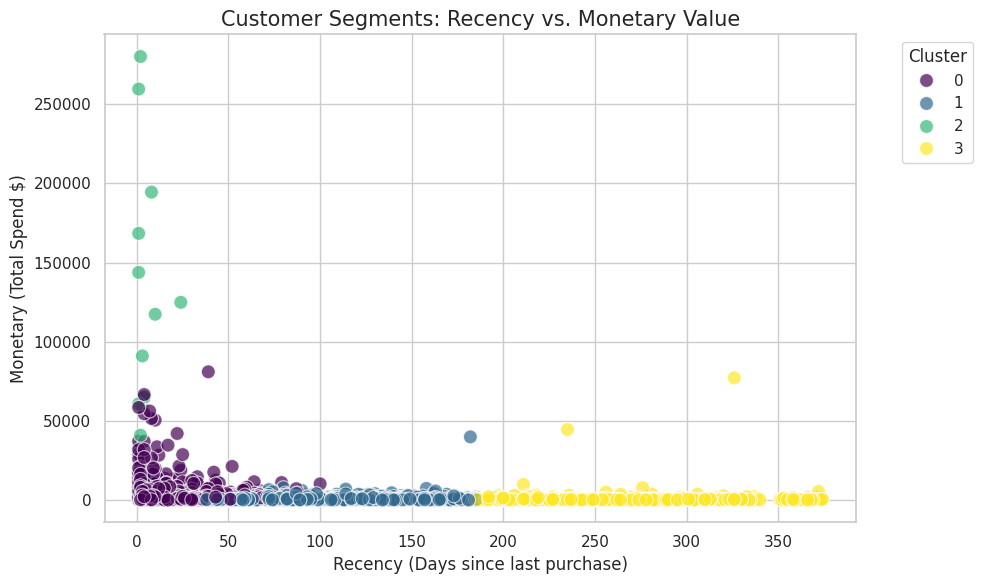

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# Using the 'rfm' dataframe created in the previous step
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster',
                palette='viridis', s=100, alpha=0.7)

plt.title('Customer Segments: Recency vs. Monetary Value', fontsize=15)
plt.xlabel('Recency (Days since last purchase)', fontsize=12)
plt.ylabel('Monetary (Total Spend $)', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

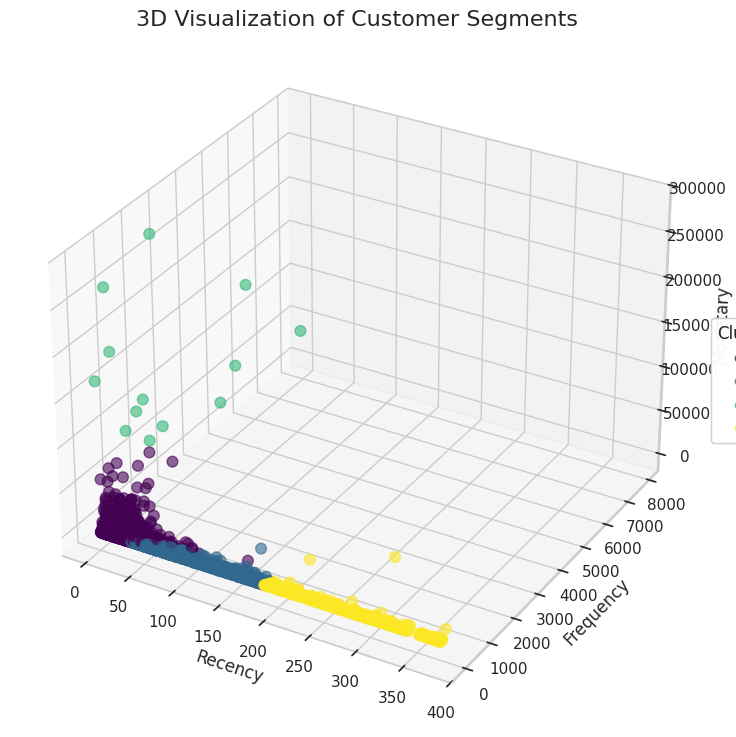

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using all three RFM dimensions
scatter = ax.scatter(rfm['Recency'],
                    rfm['Frequency'],
                    rfm['Monetary'],
                    c=rfm['Cluster'],
                    cmap='viridis',
                    s=60,
                    alpha=0.6)

# Labels and Title
ax.set_title('3D Visualization of Customer Segments', fontsize=16)
ax.set_xlabel('Recency', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_zlabel('Monetary', fontsize=12)

# Add a color bar
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters", loc='center left', bbox_to_anchor=(1, 0.5))
ax.add_artist(legend1)

plt.show()